<a href="https://colab.research.google.com/github/GuilhermeFernandez/climate_resilient_pastures/blob/main/Esboco_Projeto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Parte 1
### Objetivos:

Foco: Definir a base estática e limpar os polígonos.

Devo gerar um GeoJSON/Dataframe contendo:

1.   ID_Area: Identificador único; ✅
2.   nm_mun: município do polígono; ✅
3. classe_manejo: Categoria fixa (Extensivo, Rotacionado, SSP Nativas, SSP Exóticas);
4. geometry: Polígono da propriedade; ✅
5. area_ha: Área calculada da geometria útil. ✅
6. date_implementation: Ano em que o sistema foi implantado.
7. %_cobertura_arborea: calculada com modelo baseado em CBERS-4A, imagens de 2025 (se possível), máscara de recorte com buffer de 1pixel 8x8. ✅ (parcialmente)










### Importando Bibliotecas necessárias

In [185]:
!pip install geobr
!pip install git+https://github.com/cgarrard/osgeopy-code.git#subdirectory=ospybook
!pip install pyMannKendall
import sys, os, geobr
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

  Cloning https://github.com/cgarrard/osgeopy-code.git to /tmp/pip-req-build-5g2_rnrt
  Running command git clone --filter=blob:none --quiet https://github.com/cgarrard/osgeopy-code.git /tmp/pip-req-build-5g2_rnrt
  Resolved https://github.com/cgarrard/osgeopy-code.git to commit bc85f4ec7a630b53502ee491e400057b67cdab22
  Preparing metadata (setup.py) ... done


### Definindo diretório

In [186]:
path = '/content/drive/MyDrive/Colab Notebooks/Esboco_Projeto'
files = [f for f in os.listdir(path) if f.endswith('.shp')]

### Extraindo geometrias dos shapefiles no diretório

In [187]:
gdfs = []

for file in files:
    full_path = os.path.join(path, file)
    try:
        gdf_temp = gpd.read_file(full_path)
        gdfs.append(gdf_temp)
    except Exception as e:
        print(f"Erro ao ler {file}: {e}")

if gdfs:
    gdf = pd.concat(gdfs, ignore_index=True)

    #Ajuste de Projeção para Cálculo de Área:
    if gdf.crs is None:
        gdf.set_crs(epsg=32721, inplace=True) # Assumindo UTM 21S se não tiver nada -- já que a área de estudo é no Mato Grosso
    else:
        gdf = gdf.to_crs(epsg=32721) # Convertendo para UTM 21S se estiver em outro

    #Calculo da área:
    gdf['Area_ha'] = gdf.area / 10000

    #Converte para o CRS final de saída (SIRGAS 2000 Lat/Lon):
    gdf = gdf.to_crs(epsg=4674)

    #Cria o ID para a Área de Estudo e Salva
    gdf['ID_Area'] = gdf.index + 1

    output_file = os.path.join(path, 'study_areas.geojson')
    gdf.to_file(output_file, driver='GeoJSON')
    print("Arquivo salvo com sucesso!")
else:
    print("Nenhum arquivo shapefile encontrado.")

Arquivo salvo com sucesso!


### Extraindo município das coordenadas a partir de IBGE 2024

In [188]:
municipalities = geobr.read_municipality(code_muni='MT', year=2024)
gdf_mun = gpd.sjoin(gdf, municipalities[['name_muni', 'geometry']],
                             how='left',
                             predicate='intersects')
gdf_mun = gdf_mun.drop(['index_right', 'id'], axis=1)
gdf_mun.columns = ['geometry','area_ha','ID_Area','nm_mun']
gdf_mun['date_implementation'] = 0

gdf_mun.to_file('study_areas.geojson', driver='GeoJSON')

### Criando Modelo Random Forest

In [189]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
import rasterio
import numpy as np
from rasterio.mask import mask


gdf_treino = gpd.read_file('/content/drive/MyDrive/Colab Notebooks/Esboco_Projeto/Treino/classificacaoSupervisionada08_12_mesclado_SEMSOMBRA.shp')
caminho_tif = '/content/drive/MyDrive/Colab Notebooks/Esboco_Projeto/Treino/PAN.tif'
coluna_classe = 'Classe'

lista_de_pixels = []
with rasterio.open(caminho_tif) as src:
  if gdf_treino.crs != src.crs:
    gdf_treino = gdf_treino.to_crs(src.crs)

  for index, row in gdf_treino.iterrows():
    geometria = [row['geometry']]
    classe_atual = row[coluna_classe]

    out_image, out_transform = mask(src, geometria, crop=True)

    num_bandas = out_image.shape[0]

    pixels = out_image.transpose(1, 2, 0).reshape(-1, num_bandas)
    pixels_validos = pixels[np.sum(pixels, axis=1) > 0]

    nomes_colunas = [f'Banda_{i+1}' for i in range(num_bandas)]
    df_temp = pd.DataFrame(pixels_validos, columns=nomes_colunas)
    df_temp['Target'] = classe_atual
    lista_de_pixels.append(df_temp)

df_treinamento = pd.concat(lista_de_pixels, ignore_index=True)
df_treinamento['Target'] = df_treinamento['Target'].astype(int)

X = df_treinamento.drop(columns=['Target'])
y = df_treinamento['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=44522,
    stratify=y
)

modelo_RF = RandomForestClassifier(random_state=44522, max_depth=7)
modelo_RF.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, random_state=44522)

### Testando criar um fluxo de melhoria do modelo:

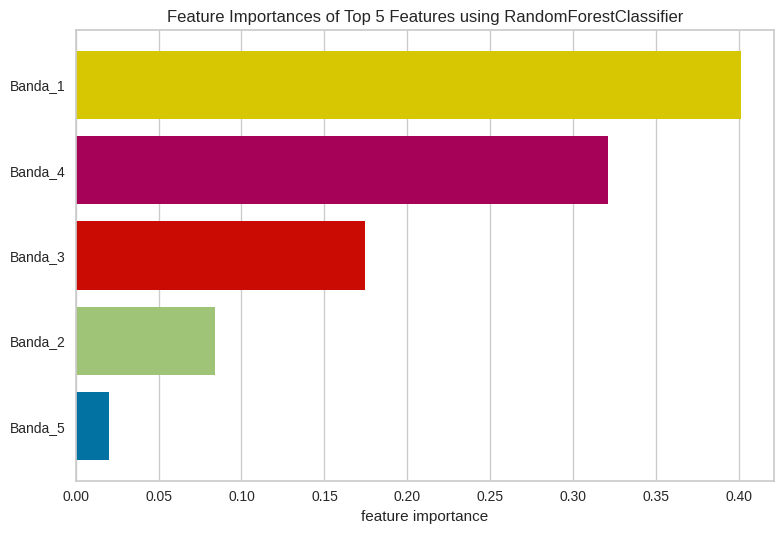

<Axes: title={'center': 'Feature Importances of Top 5 Features using RandomForestClassifier'}, xlabel='feature importance'>

In [190]:
from yellowbrick.classifier import ConfusionMatrix, ClassificationReport
from yellowbrick.model_selection import FeatureImportances
from yellowbrick.datasets import load_occupancy

#Ver direitinho qual é cada banda posteriormente, pois acredito que os números podem estar trocados.
viz = FeatureImportances(modelo_RF, relative=False, topn=5)
viz.fit(X_train, y_train)
viz.show()

In [191]:
importances = modelo_RF.feature_importances_

feature_importances = pd.DataFrame({'Features': X_train.columns, 'Importances': importances})
feature_importances.sort_values('Importances', ascending=False)

,Features,Importances
0,Banda_1,0.400927
3,Banda_4,0.320752
2,Banda_3,0.174364
1,Banda_2,0.083869
4,Banda_5,0.020087


In [192]:
from sklearn.metrics import accuracy_score
y_pred = modelo_RF.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Acurácia do modelo: {accuracy * 100:.2f}%")

Acurácia do modelo: 99.96%


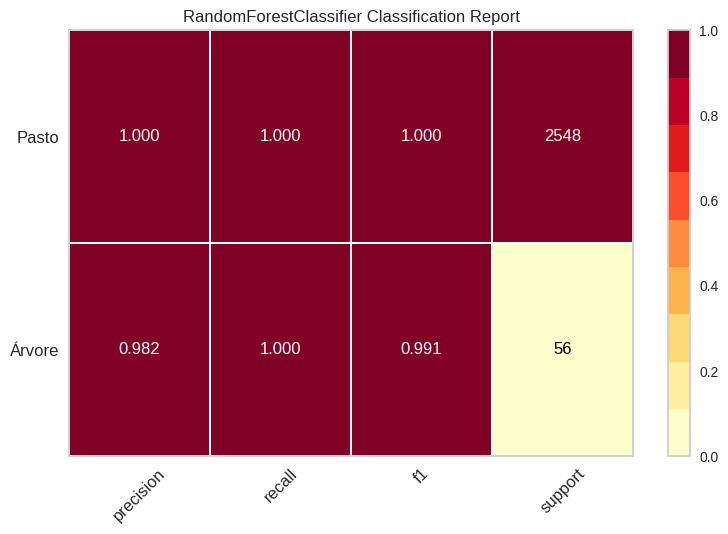

<Axes: title={'center': 'RandomForestClassifier Classification Report'}>

In [193]:
import graphviz
from yellowbrick.classifier import ConfusionMatrix, ClassificationReport
from yellowbrick.model_selection import FeatureImportances

classes = ["Árvore", "Pasto"]
visualizer = ClassificationReport(modelo_RF, classes=classes, support=True)

visualizer.fit(X_train, y_train)
visualizer.score(X_test, y_test)
visualizer.show()

In [194]:
from sklearn.metrics import classification_report

resultados_df = pd.DataFrame(index=['Precisão_Árvore', 'Recall_Árvore', 'F1-Score_Árvore', 'Suporte_Árvore','Precisão_Pasto', 'Recall_Pasto', 'F1-Score_Pasto', 'Suporte_Pasto'])

x_treino__df = pd.DataFrame(X_train)
x_teste__df = pd.DataFrame(X_test)

for count in [1, 2, 3, 4, 5]:
    selected_features = feature_importances['Features'].values[:count]

    x_treino_selecionado = x_treino__df[selected_features]
    x_teste_selecionado = x_teste__df[selected_features]

    modelo_RF.fit(x_treino_selecionado, y_train)

    y_pred = modelo_RF.predict(x_teste_selecionado)

    metricas = classification_report(y_test, y_pred, target_names=classes, output_dict=True)

    # Extrair as métricas para a classe 'Árvore' e 'Pasto'
    precision_Árvore = metricas['Árvore']['precision']
    recall_Árvore = metricas['Árvore']['recall']
    f1_Árvore = metricas['Árvore']['f1-score']
    support_Árvore = metricas['Árvore']['support']
    precision_Pasto = metricas['Pasto']['precision']
    recall_Pasto = metricas['Pasto']['recall']
    f1_Pasto = metricas['Pasto']['f1-score']
    support_Pasto = metricas['Pasto']['support']

    resultados_df[count] = [precision_Árvore, recall_Árvore, f1_Árvore, support_Árvore, precision_Pasto, recall_Pasto, f1_Pasto, support_Pasto]

resultados_df

,1,2,3,4,5
Precisão_Árvore,1.000000,0.982456,0.982456,0.982456,0.982456
Recall_Árvore,0.928571,1.000000,1.000000,1.000000,1.000000
F1-Score_Árvore,0.962963,0.991150,0.991150,0.991150,0.991150
Suporte_Árvore,56.000000,56.000000,56.000000,56.000000,56.000000
Precisão_Pasto,0.998433,1.000000,1.000000,1.000000,1.000000
Recall_Pasto,1.000000,0.999608,0.999608,0.999608,0.999608
F1-Score_Pasto,0.999216,0.999804,0.999804,0.999804,0.999804
Suporte_Pasto,2548.000000,2548.000000,2548.000000,2548.000000,2548.000000


In [195]:
feature_selecionada = feature_importances['Features'].values[:5]

X_dt = pd.DataFrame(X)
X_feature_selecionada = X_dt[feature_selecionada]

X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_feature_selecionada,
    y,
    test_size=0.30,
    random_state=44522,
    stratify=y
)

#### Otimizando parâmetros:

In [196]:
param_grid = {
      'max_depth': [3, 5, 7, 9, 11],
      'min_samples_leaf': [1, 2, 3],
      'min_samples_split': [2, 3],
      'random_state': [44522]
 }

In [197]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=44522)

model_grid = GridSearchCV(RandomForestClassifier(random_state=44522), param_grid=param_grid,
             scoring='f1', cv=cv)

model_grid.fit(X_train_dt, y_train_dt)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=44522, shuffle=True),
             estimator=RandomForestClassifier(random_state=44522),
             param_grid={'max_depth': [3, 5, 7, 9, 11],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3], 'random_state': [44522]},
             scoring='f1')

In [198]:
model_grid.best_params_

{'max_depth': 3,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'random_state': 44522}

In [199]:
y_pred_dt = model_grid.best_estimator_.predict(X_test_dt)
metricas = classification_report(y_test_dt, y_pred_dt, target_names=classes, output_dict=True)

precision_Árvore = metricas['Árvore']['precision']
recall_Árvore = metricas['Árvore']['recall']
f1_Árvore = metricas['Árvore']['f1-score']
support_Árvore = metricas['Árvore']['support']
precision_Pasto = metricas['Pasto']['precision']
recall_Pasto = metricas['Pasto']['recall']
f1_Pasto = metricas['Pasto']['f1-score']
support_Pasto = metricas['Pasto']['support']
resultados_final = [
    precision_Árvore, recall_Árvore, f1_Árvore, support_Árvore,
    precision_Pasto, recall_Pasto, f1_Pasto, support_Pasto
]

resultados_final_df = pd.DataFrame(
    resultados_final,
    index=['Precisão_Árvore', 'Recall_Árvore', 'F1-Score_Árvore', 'Suporte_Árvore',
           'Precisão_Pasto', 'Recall_Pasto', 'F1-Score_Pasto', 'Suporte_Pasto'],
    columns=['Métricas do Modelo Otimizado']
)

resultados_final_df

,Métricas do Modelo Otimizado
Precisão_Árvore,0.982143
Recall_Árvore,0.982143
F1-Score_Árvore,0.982143
Suporte_Árvore,56.000000
Precisão_Pasto,0.999608
Recall_Pasto,0.999608
F1-Score_Pasto,0.999608
Suporte_Pasto,2548.000000


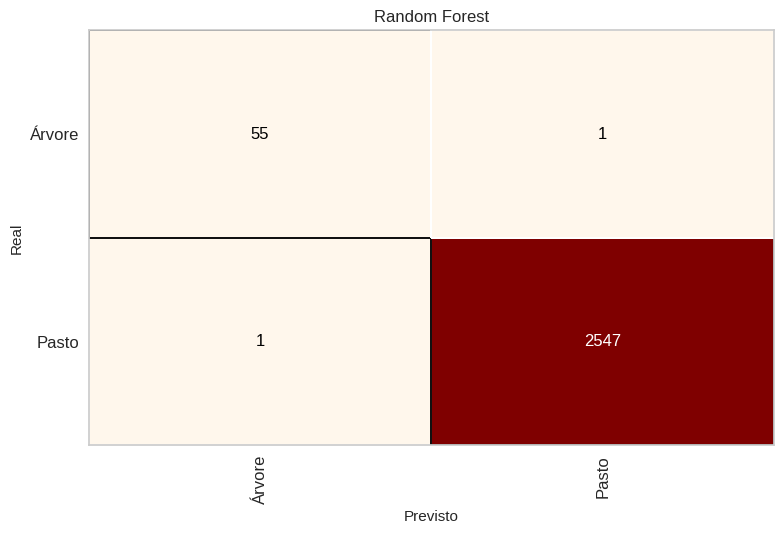

In [200]:
viz = ConfusionMatrix(model_grid.best_estimator_, classes=classes, support=True, cmap='OrRd')
viz.fit(X_train_dt, y_train_dt)
viz.score(X_test_dt, y_test_dt)

viz.finalize()

viz.ax.set_xlabel('Previsto')
viz.ax.set_ylabel('Real')
viz.ax.set_title('Random Forest')

plt.savefig('matriz_confusao_RF.png', bbox_inches='tight', dpi=600)
plt.show()

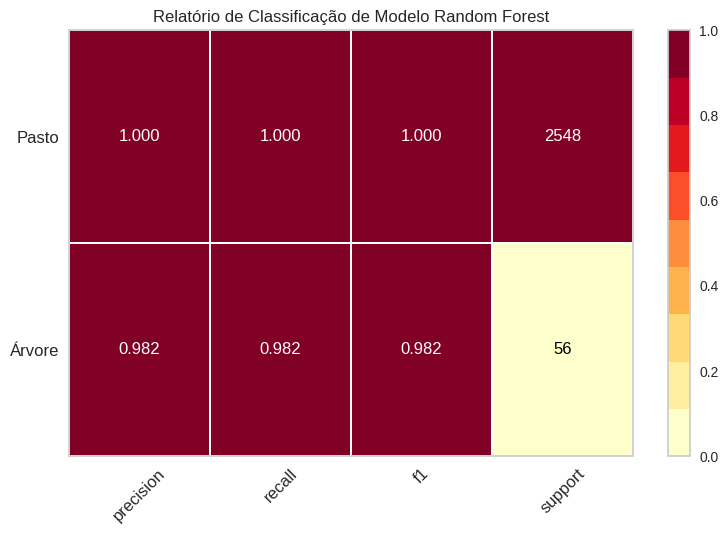

In [201]:
visualizer = ClassificationReport(model_grid.best_estimator_, classes=classes, support=True)

visualizer.fit(X_train_dt, y_train_dt)
visualizer.score(X_test_dt, y_test_dt)
visualizer.finalize()
visualizer.ax.set_title('Relatório de Classificação de Modelo Random Forest')

plt.savefig('relatorio_RF.png', bbox_inches='tight', dpi=600)
plt.show()

In [202]:
import pickle
with open('modelo_RF.pkl', 'wb') as f:
    pickle.dump(model_grid.best_estimator_, f)

### Carregando Modelo Random Forest

In [203]:
import os
import geopandas as gpd
import ospybook as pb

with open('modelo_RF.pkl', 'rb') as f:
    cob_arborea = pickle.load(f)

### Recuperando imagens PANSHARPENING para aplicação de Modelo

In [204]:
gdf = gpd.read_file('/content/study_areas.geojson')
gdf = gdf.to_crs(epsg=4674)

### Aplicação de Modelo

In [206]:
gdf_model_list = []

for index, row in gdf.iterrows():
  id_area = str(int(row['ID_Area']))
  geom = row['geometry']
  area_ha = row.get('area_ha', None)
  nm_mun = row.get('nm_mun', None)
  path_pan = f'/content/drive/MyDrive/Colab Notebooks/Esboco_Projeto/{id_area}'
  if not os.path.exists(path_pan):
    print(f"Aviso: Pasta não encontrada para ID_Area {id_area}")
    continue

  files_pan = [f for f in os.listdir(path_pan) if f.endswith('.tif')]
  for file_name in files_pan:
        full_file_path = os.path.join(path_pan, file_name)
        #Trecho tirado de "Geoprocessing with Python" - Chris Garrard (pg.282)
        data = pb.stack_bands([full_file_path])
        rows, cols, bands = data.shape
        data2d = np.reshape(data, (rows * cols, bands))

        prediction = cob_arborea.predict(data2d)
        prediction = np.reshape(prediction, (rows, cols))
        prediction = 1 - prediction

        mascara_fundo = np.sum(data, axis=2) == 0
        prediction[mascara_fundo] = 255


        valor_classe_arvore = 1
        pixels_validos = np.sum(~mascara_fundo)
        pixels_arvore = np.sum(prediction == valor_classe_arvore)
        if pixels_validos > 0:
            perc_cob_arborea = (pixels_arvore / pixels_validos) * 100
        else:
            perc_cob_arborea = 0

        with rasterio.open(full_file_path) as src:
            metadados = src.meta.copy()

        metadados.update({
            'count': 1,
            'dtype': 'uint8',
            'nodata': 255
        })

        # Arquivo no Drive
        nome_output = f'classificacao_{id_area}_{file_name}'
        caminho_output = os.path.join(path_pan, nome_output)

        with rasterio.open(caminho_output, 'w', **metadados) as dst:
            dst.write(prediction.astype(rasterio.uint8), 1)

        gdf_model_list.append({
            'ID_Area': id_area,
            'geometry': geom,
            'area_ha': area_ha,
            'nm_mun': nm_mun,
            'arquivo_tif': file_name,
            'perc_cob_arborea': perc_cob_arborea
        })

gdf_final = gpd.GeoDataFrame(gdf_model_list, crs=gdf.crs)
print(f"Processamento concluído. {len(gdf_final)} imagens analisadas e TIFs gerados.")

Processamento concluído. 1 imagens analisadas e TIFs gerados.


In [207]:
gdf_final

,ID_Area,geometry,area_ha,nm_mun,arquivo_tif,perc_cob_arborea
0,1,"POLYGON ((-55.38248 -10.21095, -55.38102 -10.2...",165.78976,Nova Guarita,PAN.tif,72.350801


### Exportando em TIF:

## Parte 2
### Objetivos:

Foco: Processamento pesado. Classificar cobertura e extrair índices para cada ano/mês dos 40 anos. A área deve ser recortada pela máscara gerada na Parte 1 para retirada de pixels com cobertura arbórea superior a 10%. Deve iterar sobre a coleção Landsat e CHIRPS e gerar um Dataframe contendo:

1.   ID_Area: Identificador único; ✅
2.   date: Ano; ✅
3. ndvi_value: Média (?) do NDVI apenas nos pixels de pasto; ✅ (por enquanto, média)
4. ndmi_value: Média (?) do NDMI; ✅ (por enquanto, média)
5. lst_value: Média (?) da temperatura de superfície;
6. precipitation_mm: Acumulado de chuva do CHIRPS para o período; ✅
7. precip_anomalies: para cada ano, True ou False. ✅


### Conectando ao projeto no Google Earth Engine e lendo o arquivo com geometrias:

In [208]:
import ee
import json

In [209]:
#Autenticando projeto
ee.Authenticate()
ee.Initialize(project='ee-guilhermefernandez')

In [210]:
#Arquivo contendo as informações geográficas
gdf = gpd.read_file('/content/study_areas.geojson')
gdf.to_crs(epsg=4674)

,area_ha,ID_Area,nm_mun,date_implementation,geometry
0,165.78976,1,Nova Guarita,0,"POLYGON ((-55.38248 -10.21095, -55.38102 -10.2..."


### Definindo anos e criando funções para coleta dos dados.
Normalizando dados do Landsat a partir de Roy et al., 2016

In [211]:
#Anos e lista para armazenamento dos dados
years = ee.List.sequence(1986, 2025)
dados_finais = []

In [212]:
#Função para calcular precipitação acumulada anual
def calculateAnnualPrecipitation(year):
    rainfallCollection = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY').select('precipitation')
    startDateYear = ee.Date.fromYMD(year, 1, 1)
    endDateYear = ee.Date.fromYMD(year, 12, 31).advance(1, 'day')
    annualRainfall = rainfallCollection.filter(ee.Filter.date(startDateYear, endDateYear)).sum()
    rainfallMean = annualRainfall.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=geom,
        scale=5566,
        maxPixels=1e9
    )
    return ee.Feature(None, {
        'year': year,
        'precipitation': rainfallMean.get('precipitation')
    })

In [213]:
#Transformando os dados brutos do LANDSAT
def apply_scale_factors(image):
    optical_bands = image.select('SR_B.').multiply(0.0000275).add(-0.2)
    return image.addBands(optical_bands, None, True)

#Criando máscara de nuvens e sombra:
def mask_clouds(image):
    qa = image.select('QA_PIXEL')
    # Bits 3 (nuvem) e 4 (sombra de nuvem)
    cloud_shadow_bit_mask = 1 << 4
    clouds_bit_mask = 1 << 3

    mask = qa.bitwiseAnd(cloud_shadow_bit_mask).eq(0) \
        .And(qa.bitwiseAnd(clouds_bit_mask).eq(0))

    return ee.Image(image.updateMask(mask).copyProperties(image, ["system:time_start"]))

In [214]:
#Harmonizando Landsat 5 e 7 ETM+ para OLI(8):
def prep_landsat_5_7(image):
    image = ee.Image(image)
    # L5/L7 Bandas: 1=Azul, 2=Verde, 3=Vermelho, 4=NIR, 5=SWIR1
    img_scaled = apply_scale_factors(image)
    img_masked = mask_clouds(img_scaled)

    renamed = img_masked.select(
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5'],
        ['Blue', 'Green', 'Red', 'NIR', 'SWIR1']
    )

    # Coeficientes de Harmonização (Roy et al., 2016):
    slopes = ee.Image.constant([0.9785, 0.9542, 0.9825, 1.0073, 1.0171])
    intercepts = ee.Image.constant([-0.0095, -0.0016, -0.0022, -0.0021, -0.0030])
    harmonized = renamed.multiply(slopes).add(intercepts)
    harmonized = harmonized.toFloat()

    return calculate_indices(ee.Image(harmonized.copyProperties(image, ["system:time_start"])))


#Renomeando as bandas de Landsat 8 e 9
def prep_landsat_8_9(image):
    # L8/L9 Bandas: 2=Azul, 3=Verde, 4=Vermelho, 5=NIR, 6=SWIR1
    img_scaled = apply_scale_factors(image)
    img_masked = mask_clouds(img_scaled)

    renamed = img_masked.select(
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6'],
        ['Blue', 'Green', 'Red', 'NIR', 'SWIR1']
    )

    renamed = renamed.toFloat()
    return calculate_indices(ee.Image(renamed.copyProperties(image, ["system:time_start"])))

In [215]:
#Função para calculo de índices:
def calculate_indices(image):
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')
    ndmi = image.normalizedDifference(['NIR', 'SWIR1']).rename('NDMI')
    return image.addBands([ndvi, ndmi])

In [216]:
#Função para pegar o índice calculado e extrair a média anual
def calcular_media_anual_landsat(year):
  #Primeiro puxando as coleções e filtrando pela área da ID_Area que vai ser usada:
  l5 = ee.ImageCollection("LANDSAT/LT05/C02/T1_L2").filterBounds(geom).filterDate(ano_inicio, ano_fim).map(prep_landsat_5_7)
  l7 = ee.ImageCollection("LANDSAT/LE07/C02/T1_L2").filterBounds(geom).filterDate(ano_inicio, ano_fim).map(prep_landsat_5_7)
  l8 = ee.ImageCollection("LANDSAT/LC08/C02/T1_L2").filterBounds(geom).filterDate(ano_inicio, ano_fim).map(prep_landsat_8_9)
  l9 = ee.ImageCollection("LANDSAT/LC09/C02/T1_L2").filterBounds(geom).filterDate(ano_inicio, ano_fim).map(prep_landsat_8_9)

  # Mesclando tudo em uma única coleção harmonizada:
  landsat_harmonizada = l5.merge(l7).merge(l8).merge(l9)

  #Métricas para calculo da média:
  startDateYear = ee.Date.fromYMD(year, 1, 1)
  endDateYear = ee.Date.fromYMD(year, 12, 31).advance(1, 'day')
  colecao_ano = landsat_harmonizada.filterDate(startDateYear, endDateYear)

  imagem_media = colecao_ano.mean()

  img_landsat_masked = imagem_media.updateMask(mask_pasto_puro)
  estatisticas = img_landsat_masked.reduceRegion(
          reducer=ee.Reducer.mean(),
          geometry=geom,
          scale=30,
          maxPixels=1e9
      )

  return ee.Feature(None, {
          'year': year,
          'NDVI_medio': estatisticas.get('NDVI'),
          'NDMI_medio': estatisticas.get('NDMI')
      })

### Execução da extração de dados:

In [229]:
import geemap
import ee
from google.colab import files
#Executando funções para cada iteração em gdf (arquivo GeoJSON):

for index, row in gdf.iterrows():
  geom = ee.Geometry(row.geometry.__geo_interface__)
  id_area = row['ID_Area'] if 'ID_Area' in gdf.columns else index
  ano_inicio = '1986-01-01'
  ano_fim = '2025-12-31'

  caminho_asset = f"projects/ee-guilhermefernandez/assets/classificacao_{id_area}_PAN"
  img_2m = ee.Image(caminho_asset)
  img_30m_frac = img_2m.reduceResolution(
    reducer=ee.Reducer.mean(),
    maxPixels=1024
  ).reproject(
    crs=img_2m.projection(),
    scale=30
  )
  mask_pasto_puro = img_30m_frac.lte(0.95) #Mascarando LANDSAT com classificação = 10% cob arbórea

  Map = geemap.Map()
  Map.centerObject(geom, 14)
  Map.addLayer(img_2m, {'min': 0, 'max': 1, 'palette': ['#f1c40f', '#27ae60']}, 'Classificação 2m (Original)')
  Map.addLayer(mask_pasto_puro, {'min': 0, 'max': 1, 'palette': ['#e74c3c', '#ffffff']}, 'Pasto Puro => 90% (30m)')
  nome_do_arquivo = f"mapa_verificacao_{id_area}.html"
  Map.to_html(nome_do_arquivo)
  files.download(nome_do_arquivo)

  #Chuva
  annualRainfallData = years.map(calculateAnnualPrecipitation)
  rainfallInfo = annualRainfallData.getInfo()

  #Média anual dos índices
  dados_anuais_landsat = years.map(calcular_media_anual_landsat)
  landsat_info = dados_anuais_landsat.getInfo()

  #Armazenando em uma lista
  for rain_feat, land_feat in zip(rainfallInfo, landsat_info):
        props_rain = rain_feat['properties']
        props_land = land_feat['properties']
        if props_land.get('NDVI_medio') is not None:
          dados_finais.append({
                'ID_Area': id_area,
                'year': props_land['year'],
                'precipitation': props_rain.get('precipitation'),
                'NDVI': props_land.get('NDVI_medio'),
                'NDMI': props_land.get('NDMI_medio')
            })

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Exportando para dataframe:

In [218]:
#Passando para um dataframe:

df_metricas = pd.DataFrame(dados_finais)
df_metricas = df_metricas.sort_values(by=['ID_Area', 'year']).reset_index(drop=True)

### Calculando 'seca extrema' (média - dp) para cada ID_Area e verificando a convergência com anos de El Niño:

In [219]:
#Calcula a média e std de precipitação para cada ID_Area, categoriza anos anômalos:

mean_precip = df_metricas.groupby('ID_Area')['precipitation'].transform('mean')
std_precip = df_metricas.groupby('ID_Area')['precipitation'].transform('std')

df_metricas['precip_anomalies'] = df_metricas['precipitation'] < (mean_precip - std_precip)

In [220]:
#Verificando convergência entre anomalies de precipitação e eventos de El Niño:

df_metricas['ElNino_anomalies'] = (df_metricas['precip_anomalies']) & (df_metricas['year'].isin([1986, 1987, 1988, 1991, 1992, 1994, 1995, 1997, 1998, 2002, 2003, 2004, 2005, 2006, 2007, 2009, 2010, 2014, 2015, 2016, 2018, 2019, 2023, 2024]))



In [221]:
#Display:

print(f'O número de anomalias (negativas) na precipitação para cada área é \n {df_metricas.groupby(['ID_Area'])['precip_anomalies'].sum()}')

print(f'O número de convergências entre anomalies e El Niño é \n {df_metricas.groupby(['ID_Area'])['ElNino_anomalies'].sum()}')

O número de anomalias (negativas) na precipitação para cada área é 
 ID_Area
1    5
Name: precip_anomalies, dtype: int64
O número de convergências entre anomalies e El Niño é 
 ID_Area
1    5
Name: ElNino_anomalies, dtype: int64


In [222]:
#Salvar em CSV:
df_metricas.to_csv('metricas.csv', index=False)

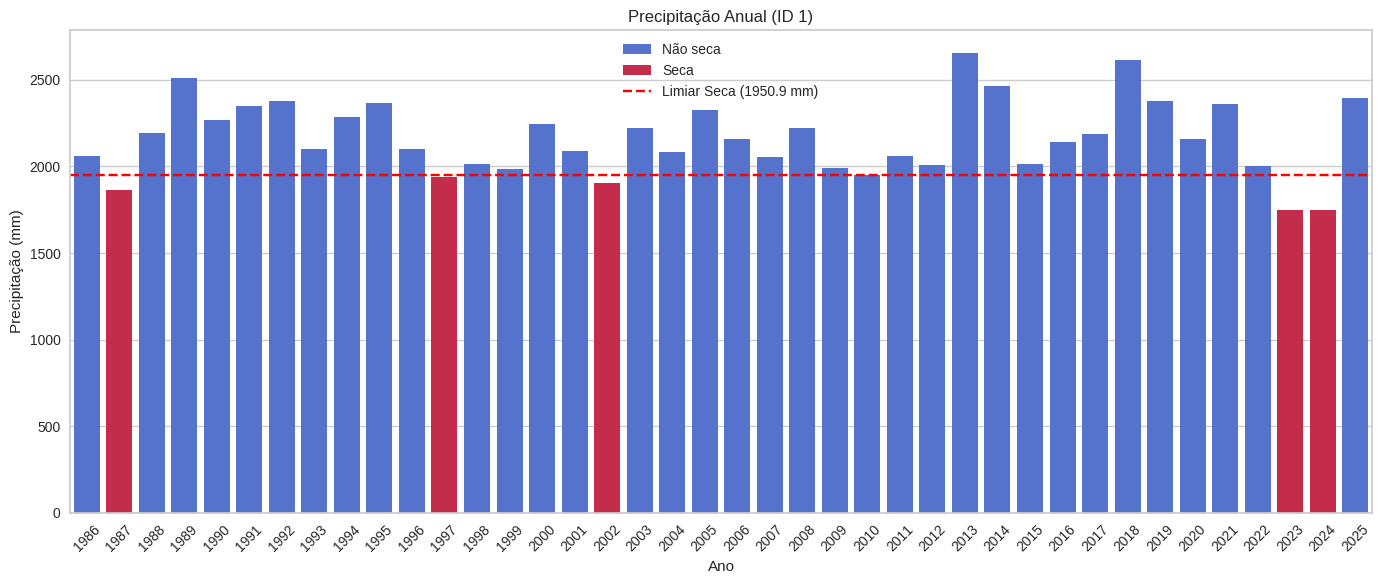

In [223]:
import seaborn as sns
import matplotlib.pyplot as plt

#Gráfico para visualizar anos considerados anômalos (abaixo da média - std):

N_AREA = 1

df_plot = df_metricas[df_metricas['ID_Area'] == N_AREA].copy()
df_plot['Status'] = df_plot['ElNino_anomalies'].replace({False: 'Não seca', True: 'Seca'})

mean_precipitation_std = df_plot['precipitation'].mean() - df_plot['precipitation'].std()

plt.figure(figsize=(14, 6))
p = sns.barplot(
    x='year',
    y='precipitation',
    data=df_plot,
    hue='Status',
    palette={'Não seca': 'royalblue', 'Seca': 'crimson'}
)

plt.axhline(
    y=mean_precipitation_std,
    color='red',
    linestyle='dashed',
    label=f'Limiar Seca ({mean_precipitation_std:.1f} mm)'
)

plt.xticks(rotation=45)
plt.title(f'Precipitação Anual (ID {N_AREA})')
plt.xlabel('Ano')
plt.ylabel('Precipitação (mm)')
plt.legend()

plt.tight_layout()
plt.savefig('seca.png', dpi=600)
plt.show()

<Axes: xlabel='precip_anomalies', ylabel='count'>

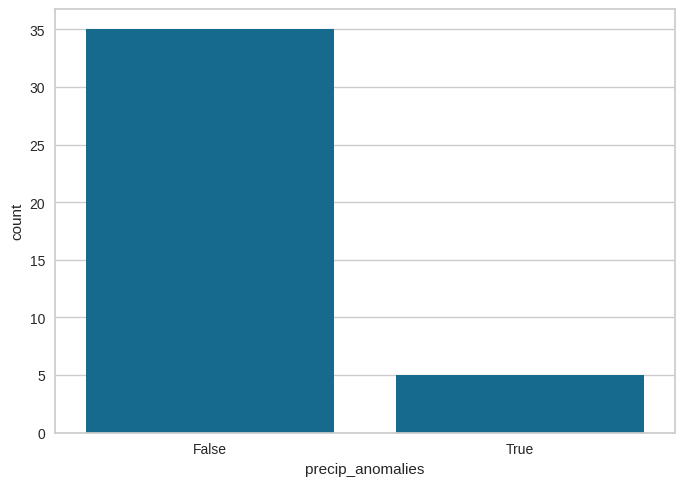

In [224]:
#Countplot mostrando a divergência entre anômalo e "normal" para a área selecionada:

N_AREA = 1
mean_precipitation_std = df_metricas[df_metricas['ID_Area'] == N_AREA]['precipitation'].mean() - df_metricas[df_metricas['ID_Area'] == N_AREA]['precipitation'].std()

sns.countplot(data=df_metricas[df_metricas['ID_Area'] == N_AREA], x='precip_anomalies', legend='full')

<Axes: xlabel='year', ylabel='NDVI'>

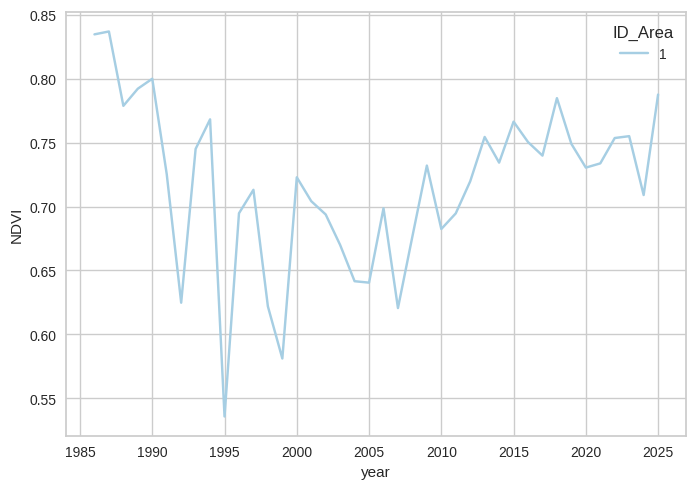

In [225]:
#Série história NDVI:

sns.lineplot(x='year', y='NDVI', data=df_metricas[df_metricas['ID_Area'] == N_AREA], palette='Paired', hue='ID_Area')

<Axes: xlabel='year', ylabel='NDMI'>

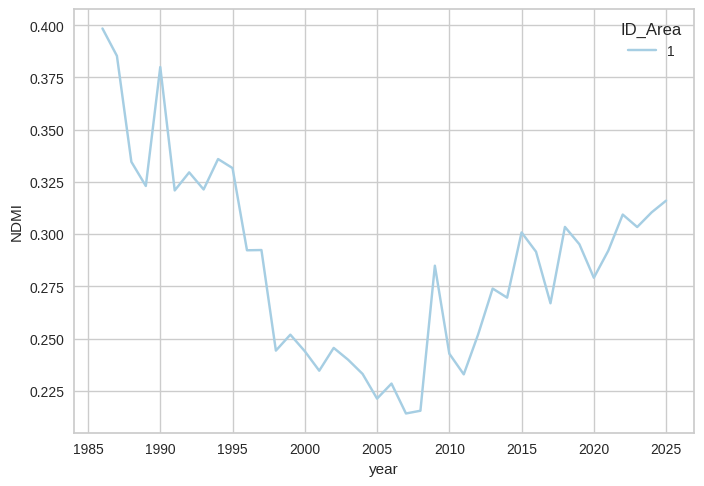

In [226]:
#Série história NDMI:

sns.lineplot(x='year', y='NDMI', data=df_metricas[df_metricas['ID_Area'] == N_AREA], palette='Paired', hue='ID_Area')

## Parte 3
### Objetivos:

Foco: Transformar dados em resultados.

Deve ler o Dataframe do Script 2 e gerar um Dataframe de Resultados contendo:


1.   ID_Area: Identificador único; ✅
2.   Index: Coluna indicando qual índice (NDVI, NDMI ou LST)✅
3. Senslope_trend_pre: Valor da inclinação da tendência ao longo da série; ✅
4. Senslope_trend_post: Valor da inclinação da tendência ao longo da série após implementação, se houver; ✅
5. trend_significance_pre: Valor-p do teste Mann-Kendall; ✅
6. trend_significance_post: Valor-p do teste Mann-Kendall; ✅
7. z_score_drought: O desvio padrão do índice durante os anos de anomalia climática (secas identificadas = precip_anomalies == True) ✅
8. comparative_resilience: Rótulo final (Brightspot, Hotspot ou Neutro) baseado na comparação com vizinhos em períodos de anomalia climática (secas identificadas = precip_anomalies == True) ✅





In [106]:
df_analise = pd.read_csv('/content/metricas.csv')

In [43]:
#df_analise = df_metricas.drop(columns="ElNino_anomalies")

In [87]:
df_analise.head()

,ID_Area,year,precipitation,NDVI,NDMI,precip_anomalies,ElNino_anomalies
0,1,1986,2060.799708,0.838497,0.403341,False,False
1,1,1987,1864.352250,0.832574,0.390249,True,True
2,1,1988,2191.557225,0.771499,0.331918,False,False
3,1,1989,2514.162230,0.773596,0.291234,False,False
4,1,1990,2266.888193,0.789552,0.360536,False,False


### NDVI

In [107]:
#Z-Score, depois extrair os anos em que tem anomalia e avaliar:
from scipy.stats import zscore
import numpy as np

df_analise['zscore_ndvi'] = df_analise.groupby('ID_Area')[['NDVI']].transform(zscore)

In [108]:
#Brightspots e Hotspots, depois extrair os anos em que tem anomalia e avaliar:

df_analise['best_NDVI'] = df_analise.groupby('year')['NDVI'].transform('quantile', q=0.8) # o código agrupa os NDVIs por ano e calcula o quartil 0.8 (80%)
df_analise['worst_NDVI'] = df_analise.groupby('year')['NDVI'].transform('quantile', q=0.2) # o código agrupa os NDVIs por ano e calcula o quartil 0.2 (20%)

conditions = [
    df_analise['NDVI'] >= df_analise['best_NDVI'], #maior que 80% dos NDVIs? Brightspot
    df_analise['NDVI'] <= df_analise['worst_NDVI'] #menor que 20% dos NDVIs? Hotspots
]
choices = ['Brightspot', 'Hotspot']

df_analise['Classificacao_NDVI'] = np.select(conditions, choices, default='Neutro') #default para que os valores intermediários sejam classificados como 'Neutro'

In [109]:
df_analise['date_implementation'] = 1999

In [110]:
import pymannkendall as mk

#Calculando slope e p_value:
df_analise['trend_slope_before_NDVI'] = np.nan
df_analise['p_value_trend_before_NDVI'] = np.nan
df_analise['trend_slope_after_NDVI'] = np.nan
df_analise['p_value_trend_after_NDVI'] = np.nan

for ID in df_analise['ID_Area'].unique():
    mascara_id = df_analise['ID_Area'] == ID
    df_area = df_analise[mascara_id]
    datas_validas = df_area['date_implementation'].dropna().unique()
    if len(datas_validas) > 0:
        ano_corte = datas_validas[0]
        mascara_before = mascara_id & (df_analise['year'] < ano_corte)
        mascara_after = mascara_id & (df_analise['year'] >= ano_corte)
        df_before = df_analise[mascara_before]
        df_after = df_analise[mascara_after]
        if len(df_before) >= 3:
            df_analise.loc[mascara_before, 'trend_slope_before_NDVI'] = mk.sens_slope(df_before['NDVI']).slope
            df_analise.loc[mascara_before, 'p_value_trend_before_NDVI'] = mk.original_test(df_before['NDVI']).p
        if len(df_after) >= 3:
            df_analise.loc[mascara_after, 'trend_slope_after_NDVI'] = mk.sens_slope(df_after['NDVI']).slope
            df_analise.loc[mascara_after, 'p_value_trend_after_NDVI'] = mk.original_test(df_after['NDVI']).p
    else:
        if len(df_area) >= 3:
            slope_geral = mk.sens_slope(df_area['NDVI']).slope
            p_val_geral = mk.original_test(df_area['NDVI']).p
            df_analise.loc[mascara_id, 'trend_slope_before_NDVI'] = slope_geral
            df_analise.loc[mascara_id, 'p_value_trend_before_NDVI'] = p_val_geral

### NDMI

In [111]:
#Z-Score, depois extrair os anos em que tem anomalia e avaliar:
from scipy.stats import zscore
import numpy as np

df_analise['zscore_ndmi'] = df_analise.groupby('ID_Area')[['NDMI']].transform(zscore)

In [112]:
#Brightspots e Hotspots, depois extrair os anos em que tem anomalia e avaliar:

df_analise['best_NDMI'] = df_analise.groupby('year')['NDMI'].transform('quantile', q=0.8) # o código agrupa os NDMIs por ano e calcula o quartil 0.8 (80%)
df_analise['worst_NDMI'] = df_analise.groupby('year')['NDMI'].transform('quantile', q=0.2) # o código agrupa os NDMIs por ano e calcula o quartil 0.2 (20%)

conditions = [
    df_analise['NDMI'] >= df_analise['best_NDMI'], #maior que 80% dos NDMIs? Brightspot
    df_analise['NDMI'] <= df_analise['worst_NDMI'] #menor que 20% dos NDMIs? Hotspots
]
choices = ['Brightspot', 'Hotspot']

df_analise['Classificacao_NDMI'] = np.select(conditions, choices, default='Neutro') #default para que os valores intermediários sejam classificados como 'Neutro'

In [113]:
import pymannkendall as mk

#Calculando slope e p_value:
df_analise['trend_slope_before_NDMI'] = np.nan
df_analise['p_value_trend_before_NDMI'] = np.nan
df_analise['trend_slope_after_NDMI'] = np.nan
df_analise['p_value_trend_after_NDMI'] = np.nan

for ID in df_analise['ID_Area'].unique():
    mascara_id = df_analise['ID_Area'] == ID
    df_area = df_analise[mascara_id]
    datas_validas = df_area['date_implementation'].dropna().unique()
    if len(datas_validas) > 0:
        ano_corte = datas_validas[0]
        mascara_before = mascara_id & (df_analise['year'] < ano_corte)
        mascara_after = mascara_id & (df_analise['year'] >= ano_corte)
        df_before = df_analise[mascara_before]
        df_after = df_analise[mascara_after]
        if len(df_before) >= 3:
            df_analise.loc[mascara_before, 'trend_slope_before_NDMI'] = mk.sens_slope(df_before['NDMI']).slope
            df_analise.loc[mascara_before, 'p_value_trend_before_NDMI'] = mk.original_test(df_before['NDMI']).p
        if len(df_after) >= 3:
            df_analise.loc[mascara_after, 'trend_slope_after_NDMI'] = mk.sens_slope(df_after['NDMI']).slope
            df_analise.loc[mascara_after, 'p_value_trend_after_NDMI'] = mk.original_test(df_after['NDMI']).p
    else:
        if len(df_area) >= 3:
            slope_geral = mk.sens_slope(df_area['NDMI']).slope
            p_val_geral = mk.original_test(df_area['NDMI']).p
            df_analise.loc[mascara_id, 'trend_slope_before_NDMI'] = slope_geral
            df_analise.loc[mascara_id, 'p_value_trend_before_NDMI'] = p_val_geral

In [114]:
df_analise

,ID_Area,year,precipitation,NDVI,NDMI,precip_anomalies,ElNino_anomalies,zscore_ndvi,best_NDVI,worst_NDVI,...,trend_slope_after_NDVI,p_value_trend_after_NDVI,zscore_ndmi,best_NDMI,worst_NDMI,Classificacao_NDMI,trend_slope_before_NDMI,p_value_trend_before_NDMI,trend_slope_after_NDMI,p_value_trend_after_NDMI
0,1,1986,2060.799708,0.838497,0.403341,False,False,2.445108,0.838497,0.838497,...,NaN,NaN,2.303067,0.403341,0.403341,Brightspot,-0.010863,0.004138,NaN,NaN
1,1,1987,1864.352250,0.832574,0.390249,True,True,2.370558,0.832574,0.832574,...,NaN,NaN,2.159824,0.390249,0.390249,Brightspot,-0.010863,0.004138,NaN,NaN
2,1,1988,2191.557225,0.771499,0.331918,False,False,1.601760,0.771499,0.771499,...,NaN,NaN,1.521628,0.331918,0.331918,Brightspot,-0.010863,0.004138,NaN,NaN
3,1,1989,2514.162230,0.773596,0.291234,False,False,1.628164,0.773596,0.773596,...,NaN,NaN,1.076497,0.291234,0.291234,Brightspot,-0.010863,0.004138,NaN,NaN
4,1,1990,2266.888193,0.789552,0.360536,False,False,1.829007,0.789552,0.789552,...,NaN,NaN,1.834734,0.360536,0.360536,Brightspot,-0.010863,0.004138,NaN,NaN
5,1,1991,2347.565198,0.717486,0.303003,False,False,0.921864,0.717486,0.717486,...,NaN,NaN,1.205261,0.303003,0.303003,Brightspot,-0.010863,0.004138,NaN,NaN
6,1,1992,2378.898900,0.612822,0.297542,False,False,-0.395625,0.612822,0.612822,...,NaN,NaN,1.145515,0.297542,0.297542,Brightspot,-0.010863,0.004138,NaN,NaN
7,1,1993,2102.339801,0.739486,0.312870,False,False,1.198795,0.739486,0.739486,...,NaN,NaN,1.313223,0.312870,0.312870,Brightspot,-0.010863,0.004138,NaN,NaN
8,1,1994,2288.600283,0.760165,0.319272,False,False,1.459089,0.760165,0.760165,...,NaN,NaN,1.383260,0.319272,0.319272,Brightspot,-0.010863,0.004138,NaN,NaN
9,1,1995,2365.948991,0.542180,0.305989,False,False,-1.284847,0.542180,0.542180,...,NaN,NaN,1.237931,0.305989,0.305989,Brightspot,-0.010863,0.004138,NaN,NaN


### Filtro

In [50]:
#Aqui dá para filtrar por anos e brightspots daqueles anos:
df_brightspots_seca = df_analise.query('precip_anomalies == True and Classificacao == "Brightspot"')

In [51]:
df_brightspots_seca.head()

,ID_Area,year,precipitation,NDVI,NDMI,precip_anomalies,ElNino_anomalies,zscore_ndvi,best_NDVI,worst_NDVI,Classificacao,date_implementation,trend_slope_before,p_value_trend_before,trend_slope_after,p_value_trend_after
1,1,1987,1864.352250,0.832574,0.390249,True,True,2.370558,0.832574,0.832574,Brightspot,1999,-0.01543,0.002795,NaN,NaN
11,1,1997,1938.349090,0.700486,0.276069,True,True,0.707871,0.700486,0.700486,Brightspot,1999,-0.01543,0.002795,NaN,NaN
16,1,2002,1904.208280,0.609970,0.138590,True,True,-0.431523,0.609970,0.609970,Brightspot,1999,NaN,NaN,0.001444,0.211002
37,1,2023,1750.879165,0.622558,0.123827,True,True,-0.273065,0.622558,0.622558,Brightspot,1999,NaN,NaN,0.001444,0.211002
38,1,2024,1748.503102,0.588714,0.152165,True,True,-0.699083,0.588714,0.588714,Brightspot,1999,NaN,NaN,0.001444,0.211002


In [52]:
df_analise.to_csv('analise.csv', index=False)

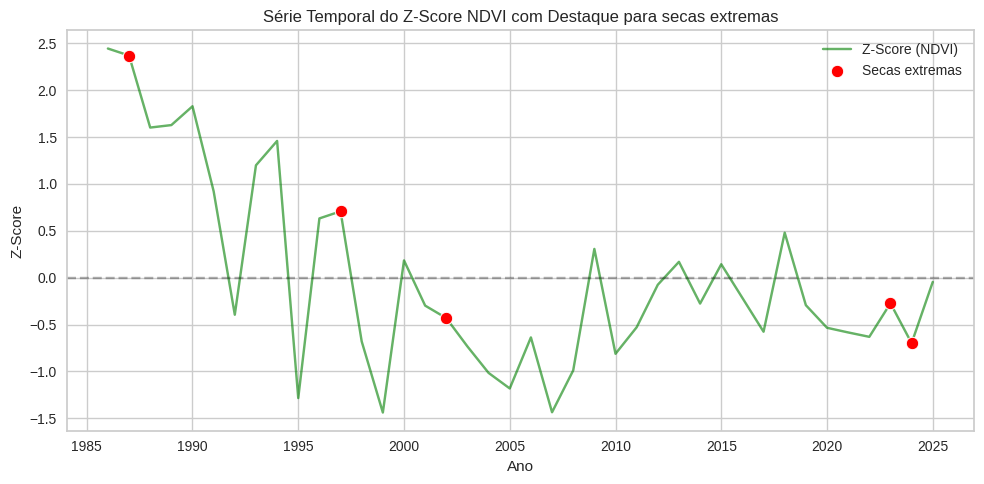

In [53]:
df_copia = df_analise.copy()
df_elnino = df_copia[df_copia['ElNino_anomalies']]

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=df_copia, x='year', y='zscore_ndvi', color='green', alpha=0.6, label='Z-Score (NDVI)', ax=ax)

sns.scatterplot(data=df_elnino, x='year', y='zscore_ndvi', color='red', s=80, marker='o', label='Secas extremas', zorder=5, ax=ax)

ax.axhline(0, color='black', linestyle='--', alpha=0.3)
ax.set_title("Série Temporal do Z-Score NDVI com Destaque para secas extremas")
ax.set_xlabel("Ano")
ax.set_ylabel("Z-Score")
ax.legend()
plt.tight_layout()
plt.savefig('serie_temporal_zscore_elnino.png', dpi=600)
plt.show()

In [54]:
df_analise

,ID_Area,year,precipitation,NDVI,NDMI,precip_anomalies,ElNino_anomalies,zscore_ndvi,best_NDVI,worst_NDVI,Classificacao,date_implementation,trend_slope_before,p_value_trend_before,trend_slope_after,p_value_trend_after
0,1,1986,2060.799708,0.838497,0.403341,False,False,2.445108,0.838497,0.838497,Brightspot,1999,-0.01543,0.002795,NaN,NaN
1,1,1987,1864.352250,0.832574,0.390249,True,True,2.370558,0.832574,0.832574,Brightspot,1999,-0.01543,0.002795,NaN,NaN
2,1,1988,2191.557225,0.771499,0.331918,False,False,1.601760,0.771499,0.771499,Brightspot,1999,-0.01543,0.002795,NaN,NaN
3,1,1989,2514.162230,0.773596,0.291234,False,False,1.628164,0.773596,0.773596,Brightspot,1999,-0.01543,0.002795,NaN,NaN
4,1,1990,2266.888193,0.789552,0.360536,False,False,1.829007,0.789552,0.789552,Brightspot,1999,-0.01543,0.002795,NaN,NaN
5,1,1991,2347.565198,0.717486,0.303003,False,False,0.921864,0.717486,0.717486,Brightspot,1999,-0.01543,0.002795,NaN,NaN
6,1,1992,2378.898900,0.612822,0.297542,False,False,-0.395625,0.612822,0.612822,Brightspot,1999,-0.01543,0.002795,NaN,NaN
7,1,1993,2102.339801,0.739486,0.312870,False,False,1.198795,0.739486,0.739486,Brightspot,1999,-0.01543,0.002795,NaN,NaN
8,1,1994,2288.600283,0.760165,0.319272,False,False,1.459089,0.760165,0.760165,Brightspot,1999,-0.01543,0.002795,NaN,NaN
9,1,1995,2365.948991,0.542180,0.305989,False,False,-1.284847,0.542180,0.542180,Brightspot,1999,-0.01543,0.002795,NaN,NaN


## Parte 4: Regressão com variáveis fictícias (Dummy)

Variáveis independentes: % de cob. arbórea, classe de manejo e precipitação (mm)

Variáveis dependentes: z-score NDVI, z-score NDMI e z-score LST

In [115]:
df_1 = gdf_final.drop(columns=['geometry', 'area_ha', 'nm_mun', 'arquivo_tif'])
df_3 = df_analise.query('precip_anomalies == True')
df_3 = df_3.drop(columns=['best_NDVI', 'worst_NDVI', 'Classificacao_NDVI', 'Classificacao_NDMI', 'trend_slope_before_NDVI', 'trend_slope_after_NDVI', 'p_value_trend_before_NDVI', 'p_value_trend_after_NDVI', 'trend_slope_before_NDMI', 'trend_slope_after_NDMI', 'p_value_trend_before_NDMI', 'p_value_trend_after_NDMI'])
df_1['ID_Area'] = df_1['ID_Area'].astype(int)

In [116]:
df_estatistica = pd.merge(df_1, df_3, on='ID_Area')

In [117]:
df_estatistica.head()

,ID_Area,perc_cob_arborea,year,precipitation,NDVI,NDMI,precip_anomalies,ElNino_anomalies,zscore_ndvi,date_implementation,zscore_ndmi,best_NDMI,worst_NDMI
0,1,27.649199,1987,1864.352250,0.832574,0.390249,True,True,2.370558,1999,2.159824,0.390249,0.390249
1,1,27.649199,1997,1938.349090,0.700486,0.276069,True,True,0.707871,1999,0.910573,0.276069,0.276069
2,1,27.649199,2002,1904.208280,0.609970,0.138590,True,True,-0.431523,1999,-0.593588,0.138590,0.138590
3,1,27.649199,2023,1750.879165,0.622558,0.123827,True,True,-0.273065,1999,-0.755112,0.123827,0.123827
4,1,27.649199,2024,1748.503102,0.588714,0.152165,True,True,-0.699083,1999,-0.445067,0.152165,0.152165


In [118]:
import statsmodels.api as sm

X = df_estatistica[['precipitation', 'perc_cob_arborea']]
X = sm.add_constant(X)

#Cada variável resposta:
y_ndmi = df_estatistica[['zscore_ndmi']]
modelo_ndvi = sm.OLS(y_ndvi, X).fit()
print("=== RESULTADOS PARA O NDVI ===")
print(modelo_ndvi.summary())

y_ndmi = df_estatistica[['zscore_ndmi']]
modelo_ndmi = sm.OLS(y_ndmi, X).fit()
print("=== RESULTADOS PARA O ndmi ===")
print(modelo_ndmi.summary())

=== RESULTADOS PARA O NDVI ===
                            OLS Regression Results                            
Dep. Variable:            zscore_ndvi   R-squared:                       0.178
Model:                            OLS   Adj. R-squared:                 -0.096
Method:                 Least Squares   F-statistic:                    0.6511
Date:                Mon, 13 Apr 2026   Prob (F-statistic):              0.479
Time:                        17:31:48   Log-Likelihood:                -7.1851
No. Observations:                   5   AIC:                             18.37
Df Residuals:                       3   BIC:                             17.59
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
precipita

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
